# The goal of this notebook is to implement a threshold based burst detector, particularly for DNM2.
## This will help extract canonical endocytic events

In [1]:
#Load all the tracks
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Load the pickle file
with open('filtered_tracks_final_aadarsh_copy.pkl', 'rb') as f:
    data = pickle.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)


In [2]:
# Load the DNM2 and AP2 channels

ap2_tracks = []
dnm2_tracks= []
for _, row in df.iterrows():
    track_id = row['track_id']

    # Parse mu_x, mu_y, mu_z: assumed to be space-separated strings
    c1 = list(row['C1_adjusted_voxel_sum'])
    c2 = list(row['C2_adjusted_voxel_sum'])
    c3 = list(row['C3_adjusted_voxel_sum'])
    ap2_tracks.append(c3)
    dnm2_tracks.append(c2)


# Pick a smaller subset for easier analysis
num_tracks = 1000
ap2 = ap2_tracks[0:num_tracks]
dnm2 = dnm2_tracks[0:num_tracks]


## Visualize some examples

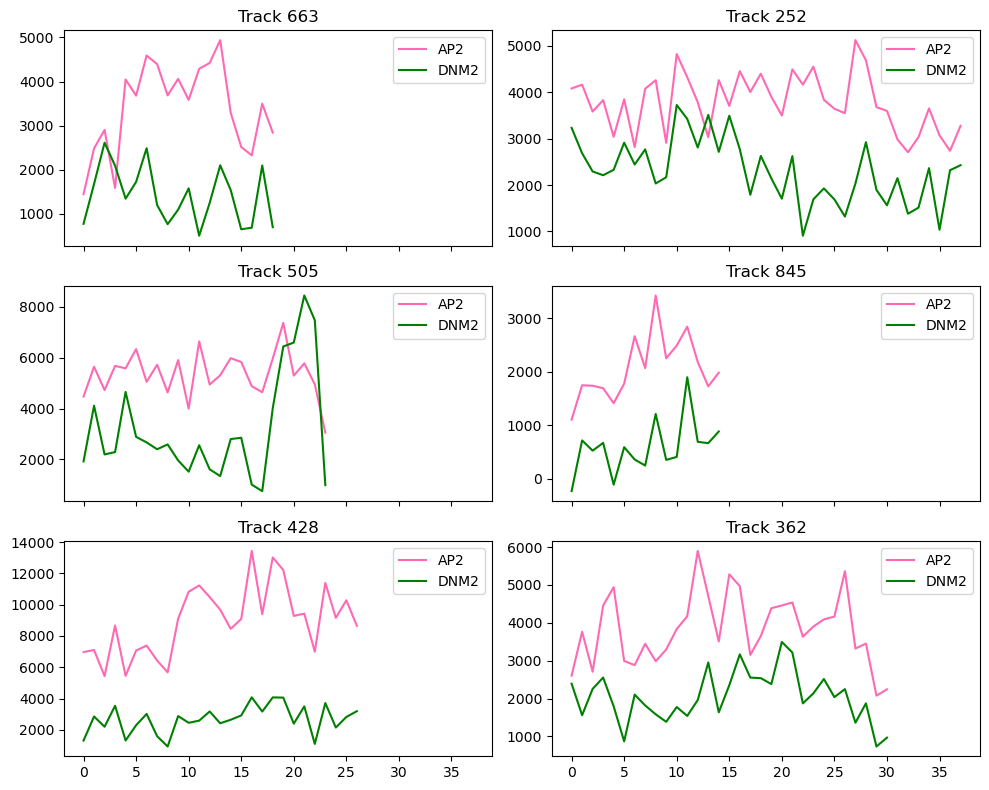

In [3]:
# Pick 6 random indices
import random
indices = random.sample(range(len(ap2)), 6)

# Create 3x2 subplots
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    t_ap2 = ap2[idx]
    t_dnm2 = dnm2[idx]
    
    # Assuming they are of equal length
    time = np.arange(len(t_ap2))
    
    ax.plot(time, t_ap2, color='hotpink', label='AP2')
    ax.plot(time, t_dnm2, color='green', label='DNM2')
    ax.set_title(f'Track {idx}')
    ax.legend()

plt.tight_layout()
plt.show()


## Improved Visualization using a moving average

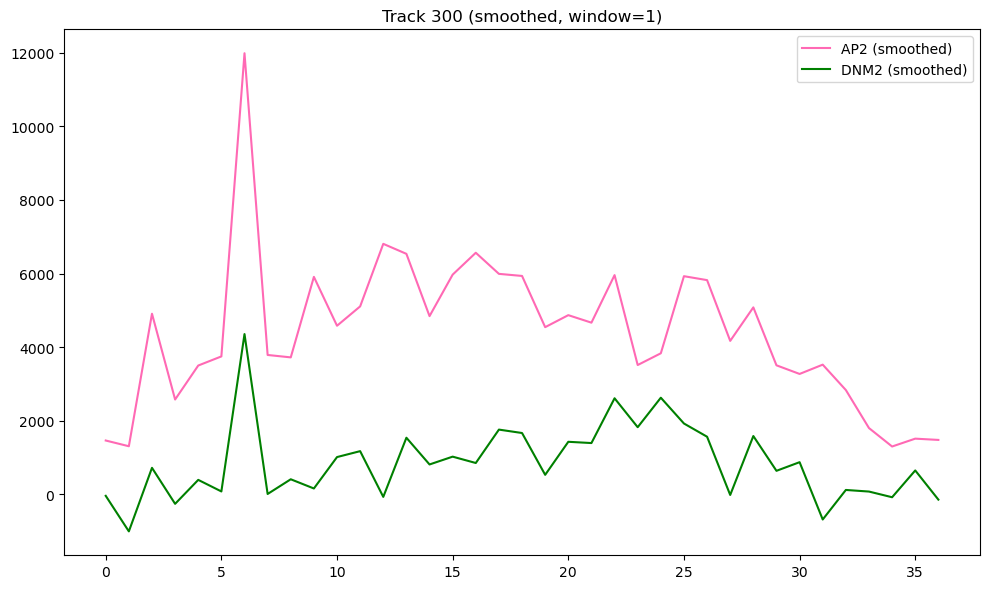

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, window_size=3):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')

idx = 300  # track index
window_size = 1  # you can adjust this for more or less smoothing (1 == no smoothing)

t_ap2 = ap2[idx]
t_dnm2 = dnm2[idx]
time = np.arange(len(t_ap2))

# Apply moving average
t_ap2_smooth = moving_average(t_ap2, window_size)
t_dnm2_smooth = moving_average(t_dnm2, window_size)

fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

ax.plot(time, t_ap2_smooth, color='hotpink', label='AP2 (smoothed)')
ax.plot(time, t_dnm2_smooth, color='green', label='DNM2 (smoothed)')
ax.set_title(f'Track {idx} (smoothed, window={window_size})')
ax.legend()

plt.tight_layout()
plt.show()


## Now the goal is to use unsmoothed data and detect peaks by comparing points that a n_sigma std deviations from the cumulative mean in both the positive and negative directions.
### This is nice because it requires only 1 parameter, number of standard deviations

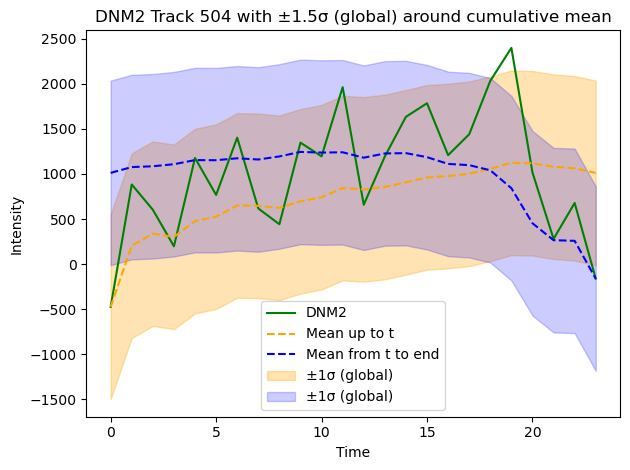

In [5]:
import numpy as np
import matplotlib.pyplot as plt

track_id = 504
t = np.array(dnm2[track_id])
n_sigma = 1.5
N = len(t)

# Global mean and std for the entire trakc
global_mean = np.mean(t)
global_std = np.std(t)

# Cumulative means to the left and right (past and future)
mean_left = np.cumsum(t) / (np.arange(N) + 1)
mean_right = np.cumsum(t[::-1])[::-1] / (np.arange(N)[::-1] + 1)

# Plotting
plt.plot(t, label='DNM2', color='green')
plt.plot(mean_left, label='Mean up to t', linestyle='--', color='orange')
plt.plot(mean_right, label='Mean from t to end', linestyle='--', color='blue')

# Use global std for shading
plt.fill_between(np.arange(N), mean_left - n_sigma*global_std, mean_left + n_sigma*global_std, color='orange', alpha=0.3, label='±1σ (global)')
plt.fill_between(np.arange(N), mean_right - n_sigma*global_std, mean_right + n_sigma*global_std, color='blue', alpha=0.2, label='±1σ (global)')

plt.title(f'DNM2 Track {track_id} with ±{n_sigma}σ (global) around cumulative mean')

plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.tight_layout()
plt.show()


# Use this logic to detect DNM2 bursts

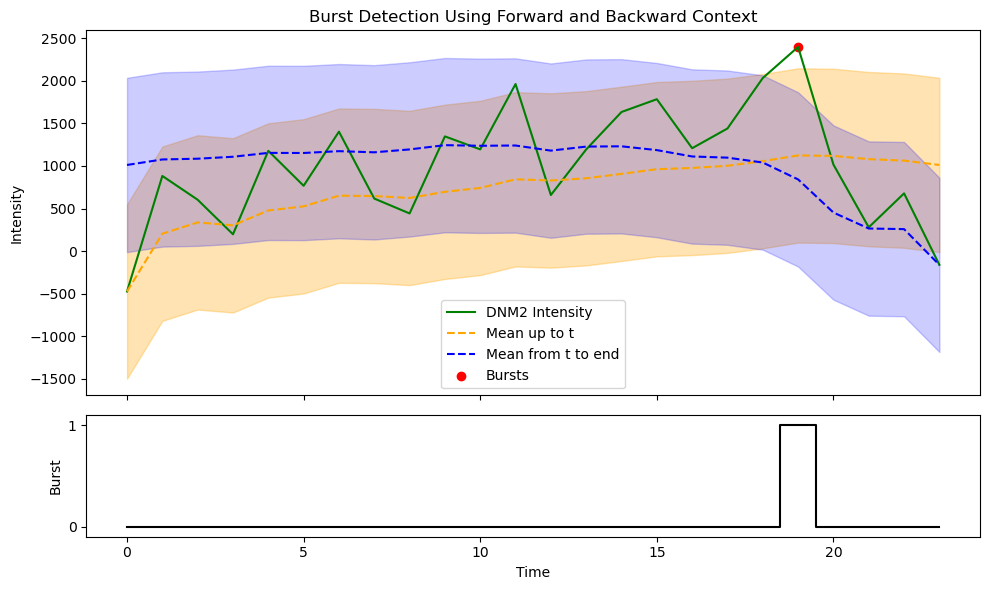

In [6]:
import numpy as np
import matplotlib.pyplot as plt

track_id = 504  # example
n_sigma = 1.5
t = np.array(dnm2[track_id])
N = len(t)

# Global stats
global_std = np.std(t)

# Rolling means
mean_left = np.cumsum(t) / (np.arange(N) + 1)
mean_right = np.cumsum(t[::-1])[::-1] / (np.arange(N)[::-1] + 1)

# Define burst mask: point must be outside both bands
burst_mask = (t > mean_left + n_sigma*global_std)
burst_mask &= (t > mean_right + n_sigma*global_std) 

# Binary signal
binary_signal = burst_mask.astype(int)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top plot: intensity with shading and means
axs[0].plot(t, label='DNM2 Intensity', color='green')
axs[0].plot(mean_left, label='Mean up to t', linestyle='--', color='orange')
axs[0].plot(mean_right, label='Mean from t to end', linestyle='--', color='blue')

axs[0].fill_between(np.arange(N), mean_left - n_sigma*global_std, mean_left + n_sigma* global_std, color='orange', alpha=0.3)
axs[0].fill_between(np.arange(N), mean_right -  n_sigma*global_std, mean_right + n_sigma*global_std, color='blue', alpha=0.2)

axs[0].scatter(np.arange(N)[burst_mask], t[burst_mask], color='red', label='Bursts')
axs[0].set_ylabel('Intensity')
axs[0].legend()
axs[0].set_title('Burst Detection Using Forward and Backward Context')

# Bottom plot: binary burst signal
axs[1].step(np.arange(N), binary_signal, where='mid', color='black')
axs[1].set_ylabel('Burst')
axs[1].set_xlabel('Time')
axs[1].set_ylim(-0.1, 1.1)
axs[1].set_yticks([0, 1])

plt.tight_layout()
plt.show()


In [7]:
# Applying the burst detection logic to all tracks

def detect_bursts(t, n_sigma=1.5):
    N = len(t)
    global_std = np.std(t)
    mean_left = np.cumsum(t) / (np.arange(N) + 1)
    mean_right = np.cumsum(t[::-1])[::-1] / (np.arange(N)[::-1] + 1)

    burst_mask = (t > mean_left + 1.5*global_std) & (t > mean_right + 1.5*global_std) # returns 1 if its higher than both the left and right means , else 0
    return burst_mask.astype(int)

def closest_distance_between_ones(arr1, arr2):
    """Given two binary arrays, find the smallest absolute time difference between any 1 in arr1 and any 1 in arr2.
    Return None if no 1's found in either."""
    idx1 = np.where(arr1 == 1)[0]
    idx2 = np.where(arr2 == 1)[0]

    if len(idx1) == 0 or len(idx2) == 0:
        return None

    # Compute all pairwise distances, take the minimum
    dists = np.abs(idx1[:, None] - idx2[None, :])
    return np.min(dists)

closest_distances = []
not_considered_count = 0

# Assuming ap2 and dnm2 are lists or arrays of tracks with the same length
for i in range(len(ap2)):
    ap2_track = np.array(ap2[i])
    dnm2_track = np.array(dnm2[i])
    
    # Skip tracks with different lengths
    if len(ap2_track) != len(dnm2_track):
        not_considered_count += 1
        continue

    ap2_bursts = detect_bursts(ap2_track)
    dnm2_bursts = detect_bursts(dnm2_track)

    dist = closest_distance_between_ones(ap2_bursts, dnm2_bursts)
    if dist is None:
        not_considered_count += 1
        closest_distances.append(-5) # Filling -5 as a placeholder for no tracks that are not considered
    else:
        closest_distances.append(dist) # Closest distance between bursts (in frames)
 
# Output
print(f"Number of tracks not considered (no bursts found or length mismatch): {not_considered_count}")
print(f"Distribution of closest burst distances (time points):")
print(np.array(closest_distances))


Number of tracks not considered (no bursts found or length mismatch): 572
Distribution of closest burst distances (time points):
[ 0  0  0  0  0  0  0 -5  0  0  0  0  0  0  0  0 -5  0  0  0  0  5  0 36
  3  0 -5 -5 -5  0 38  0  0 -5  0 -5  0  0 -5  0  0  9 -5  0  2  0  0  0
  0  0 -5 -5  0  0  1  0 -5  0  0 -5  1  0  0  0  3  0  3  0  0  0  0  0
  1 19  0 -5 -5  0  0 -5  0  0  2  0  0  0  0  0 -5  0 34  2  0  0  0  0
 -5  0  0 -5  0  3  0 26 20 -5 -5  0 -5  0  2  0  0  3 -5 -5  3 -5 -5 26
  0  0  0  0 21  1 -5  0 16  0 17  0  0  1  3 11 -5 -5  0  0  0  0  0  4
  0 -5 -5  1 18 13  0 -5 -5 -5  3 14  0  0 -5  5  0  1  0  0  0  0  0  8
  1  0  7  5 -5  0  0  0  0  0 -5  8  2 -5  6  1  0  0  0  0  0 -5 -5 -5
 -5  1 -5 11  0  0  5  0  0  0  0 -5 -5  5  0  0  4  0  0 -5  0  0  0  0
  2 -5 -5  5 -5  0 -5  0 -5  6  0 -5 10  0 -5 -5  4  2  1 -5  2 -5 -5 17
  0 -5 -5  0  0  0  0 -5  0  0  0 -5  0  2  0 -5 11 -5  0  1  1 -5 -5 -5
  5 -5 -5 -5 10 -5  0 18  0 -5  2 29  0 -5  0  1  7  1 -5  0  0 -5  

## Assuming that AP2 and DNM2 bursts are atmost 10 seconds apart, we can filter out CME sites. This is a tunable parameter according to evidence in the graph.

5
Number of tracks with distance < frame_dist frames: 342


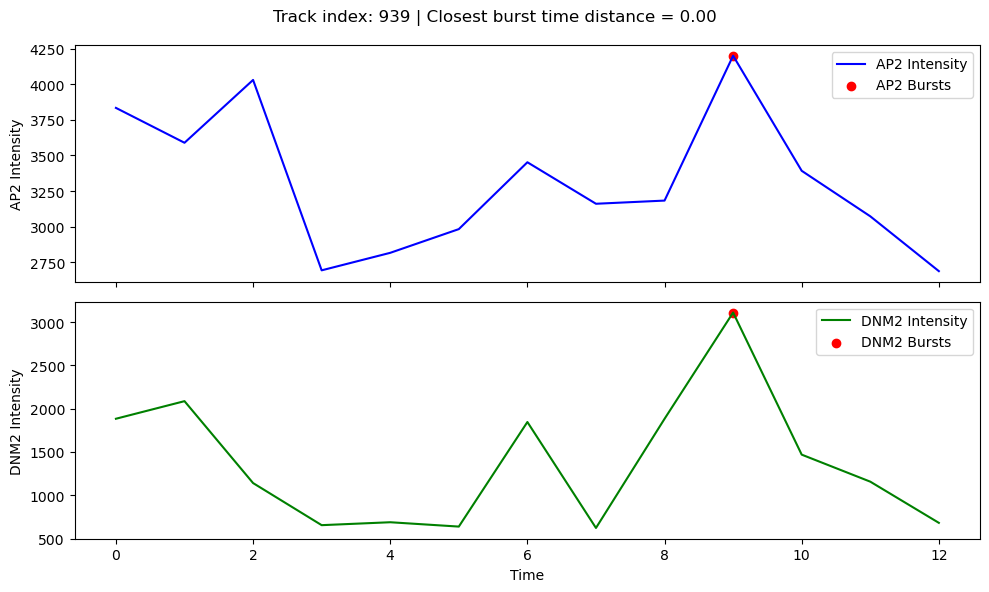

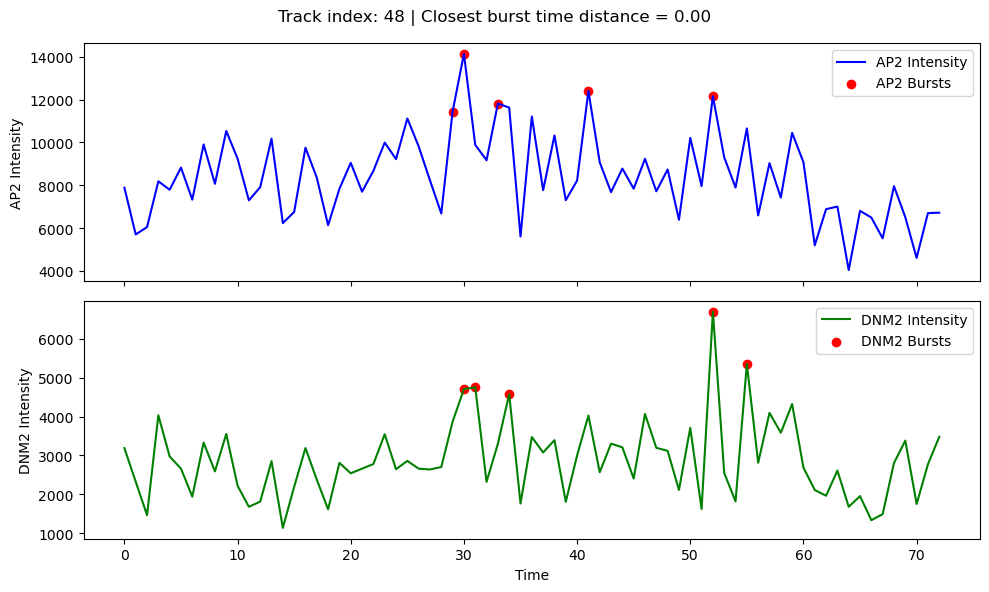

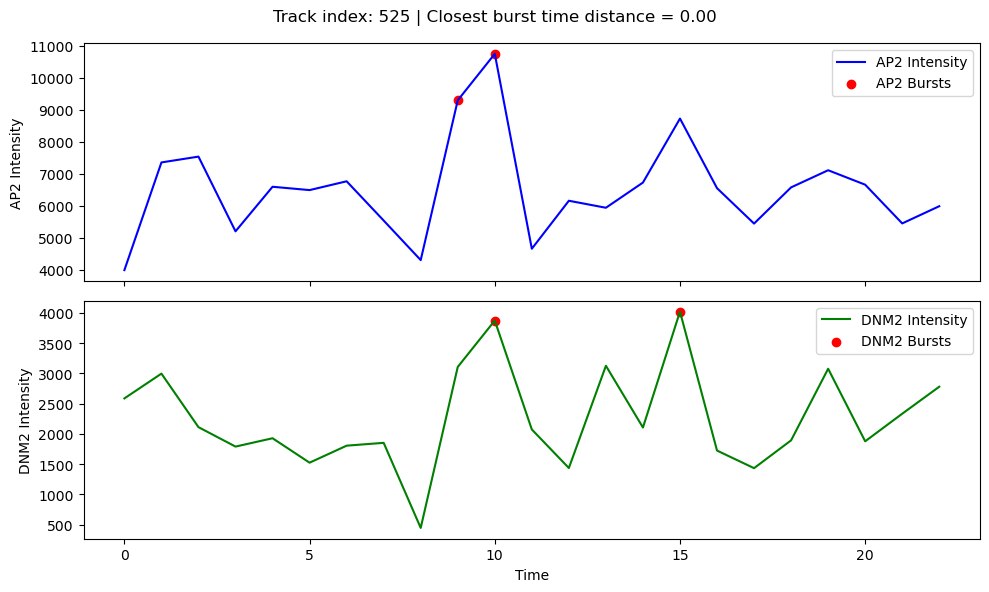

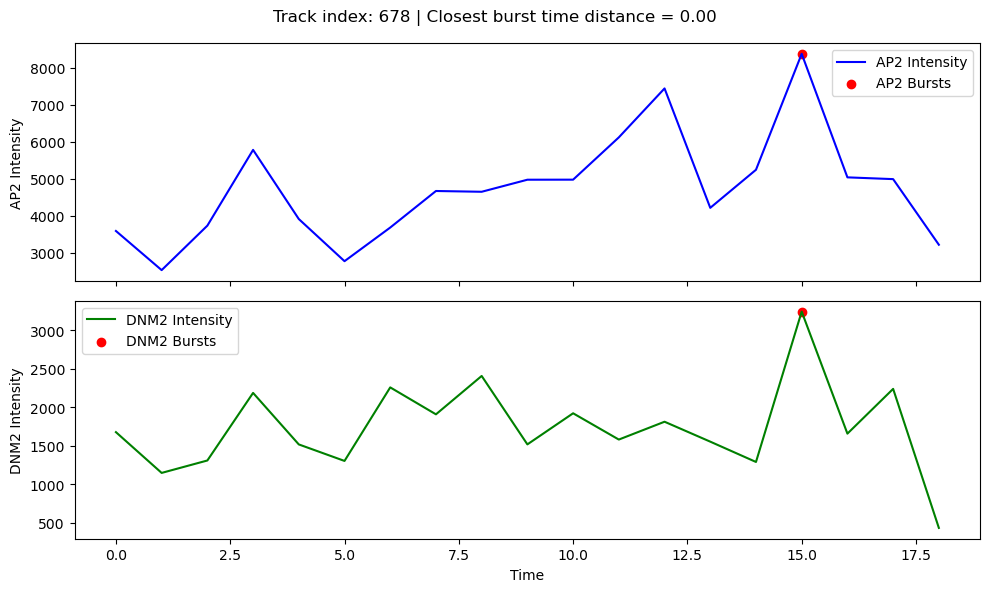

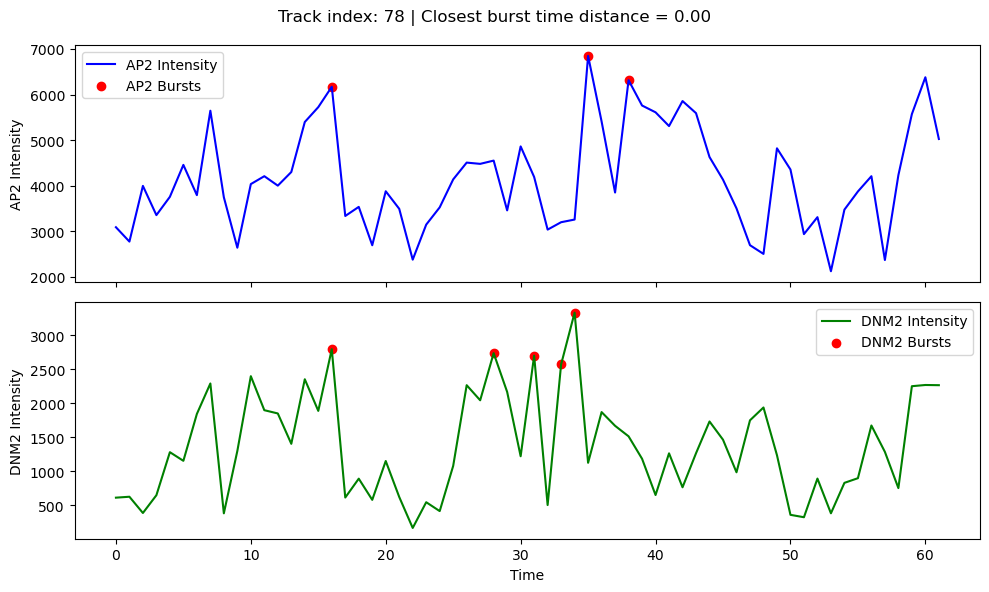

In [8]:
frame_interval = 2.5  # time per frame in your units
time_interval = 10 # second between AP2 and DNM2
frame_dist = int(time_interval//frame_interval)+1
print(frame_dist)
# Find indices of tracks where distance < frame_dist frames
zero_dist_indices = [i for i, dist in enumerate(closest_distances) if 0 <= dist < frame_dist]

print(f"Number of tracks with distance < frame_dist frames: {len(zero_dist_indices)}")

if len(zero_dist_indices) == 0:
    print("No tracks found with distance < frame_dist frames.")
else:
    # sample some random examples for visualization
    sample_indices = random.sample(zero_dist_indices, min(5, len(zero_dist_indices)))

    for idx in sample_indices:
        ap2_track = np.array(ap2[idx])
        dnm2_track = np.array(dnm2[idx])

        ap2_bursts = detect_bursts(ap2_track)
        dnm2_bursts = detect_bursts(dnm2_track)

        # Get actual time distance for this track
        time_distance = closest_distances[idx] * frame_interval

        fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        fig.suptitle(f'Track index: {idx} | Closest burst time distance = {time_distance:.2f}')

        axs[0].plot(ap2_track, label='AP2 Intensity', color='blue')
        axs[0].scatter(np.where(ap2_bursts == 1)[0], ap2_track[ap2_bursts == 1], color='red', label='AP2 Bursts')
        axs[0].legend()
        axs[0].set_ylabel('AP2 Intensity')

        axs[1].plot(dnm2_track, label='DNM2 Intensity', color='green')
        axs[1].scatter(np.where(dnm2_bursts == 1)[0], dnm2_track[dnm2_bursts == 1], color='red', label='DNM2 Bursts')
        axs[1].legend()
        axs[1].set_ylabel('DNM2 Intensity')
        axs[1].set_xlabel('Time')

        plt.tight_layout()
        plt.show()


## Putting it together to extract potential CME sites

Number of tracks with distance < frame_dist frames: 342


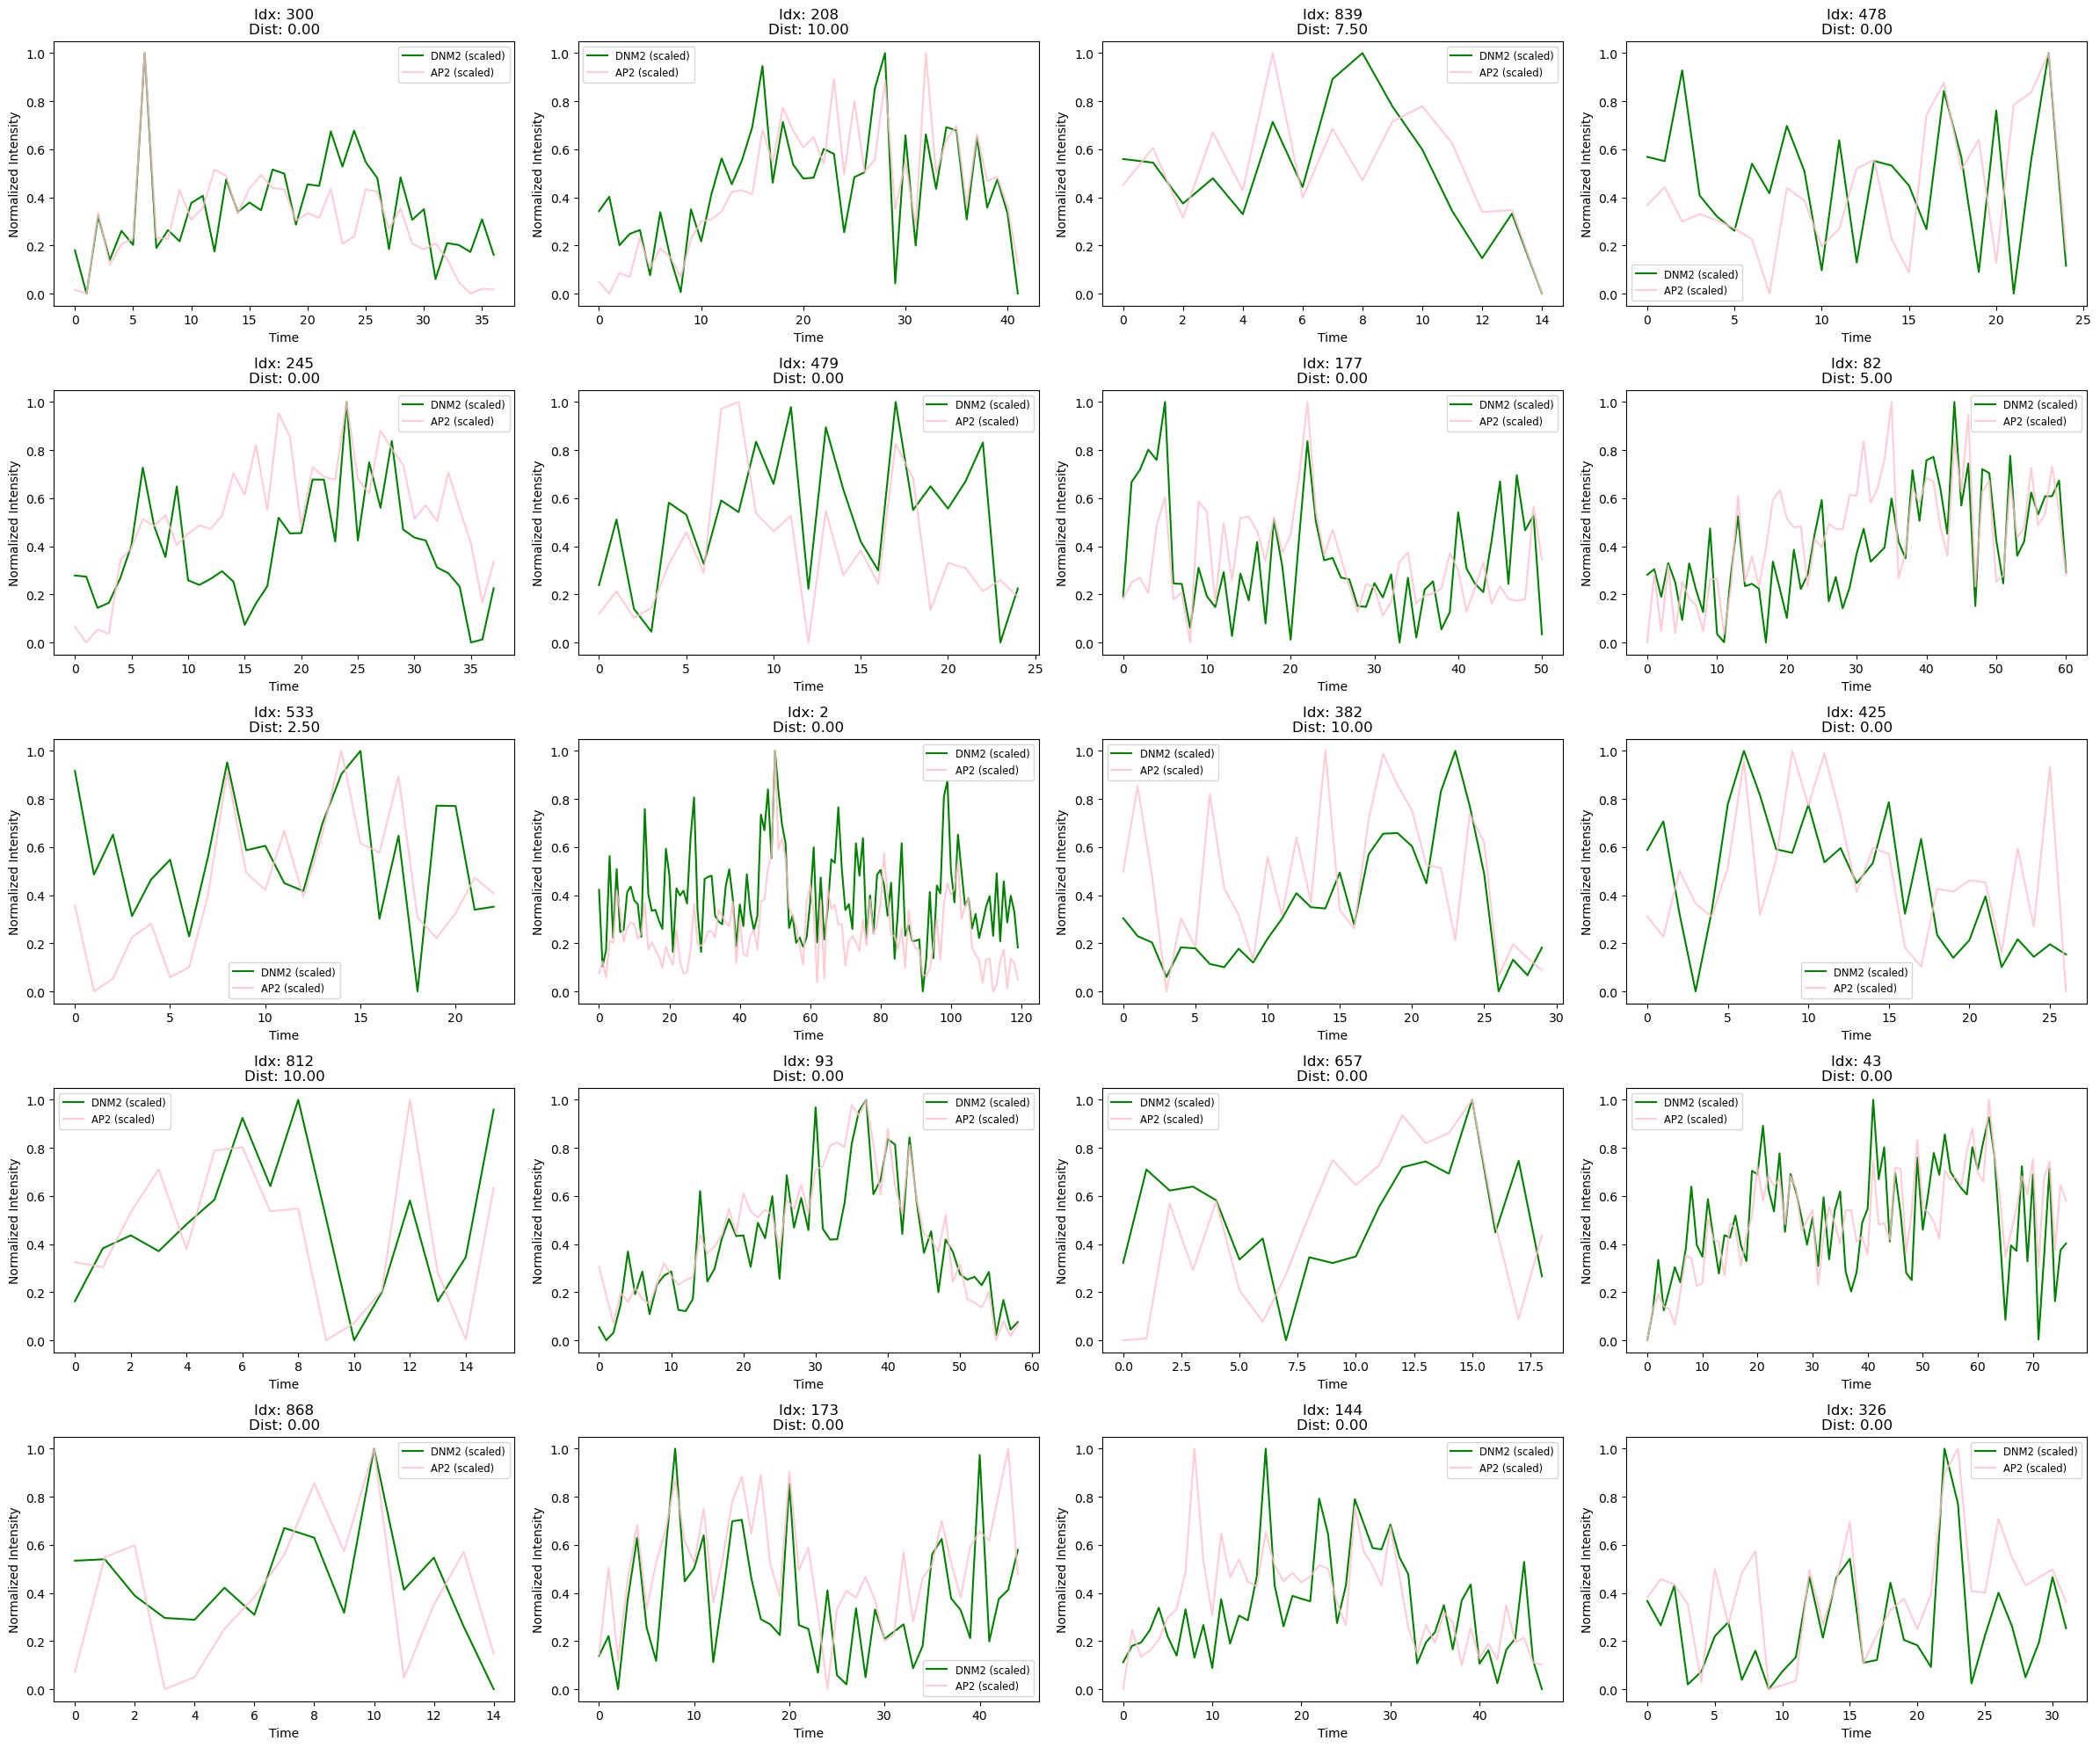

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

frame_interval = 2.5  # time per frame in your units
time_interval = 10 # second between AP2 and DNM2
frame_dist = int(time_interval//frame_interval)+1

def min_max_scale(x): # normalize tracks
    return (x - np.min(x)) / (np.max(x) - np.min(x))

# Find indices of tracks where distance < frame_dist
zero_dist_indices = [i for i, dist in enumerate(closest_distances) if 0 <= dist < frame_dist]

print(f"Number of tracks with distance < frame_dist frames: {len(zero_dist_indices)}")

if len(zero_dist_indices) == 0:
    print("No tracks found with distance < frame_dist frames.")
else:
    ## 20 random samples
    sample_size = min(20, len(zero_dist_indices))
    sample_indices = random.sample(zero_dist_indices, sample_size)

    fig, axs = plt.subplots(5, 4, figsize=(24, 20), sharex=False, sharey=False)
    axs = axs.flatten()

    for ax, idx in zip(axs, sample_indices):
        ap2_track = np.array(ap2[idx])
        dnm2_track = np.array(dnm2[idx])

        ap2_scaled = min_max_scale(ap2_track)
        dnm2_scaled = min_max_scale(dnm2_track)

        time_distance = closest_distances[idx] * frame_interval

        ax.plot(dnm2_scaled, color='green', label='DNM2 (scaled)')
        ax.plot(ap2_scaled, color='pink', label='AP2 (scaled)', alpha=0.8)
        ax.set_title(f'Idx: {idx}\nDist: {time_distance:.2f}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Normalized Intensity')
        ax.legend(fontsize='small')

    # Remove any unused subplots if less than 20 samples
    for ax in axs[sample_size:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Look at the same events with a moving average

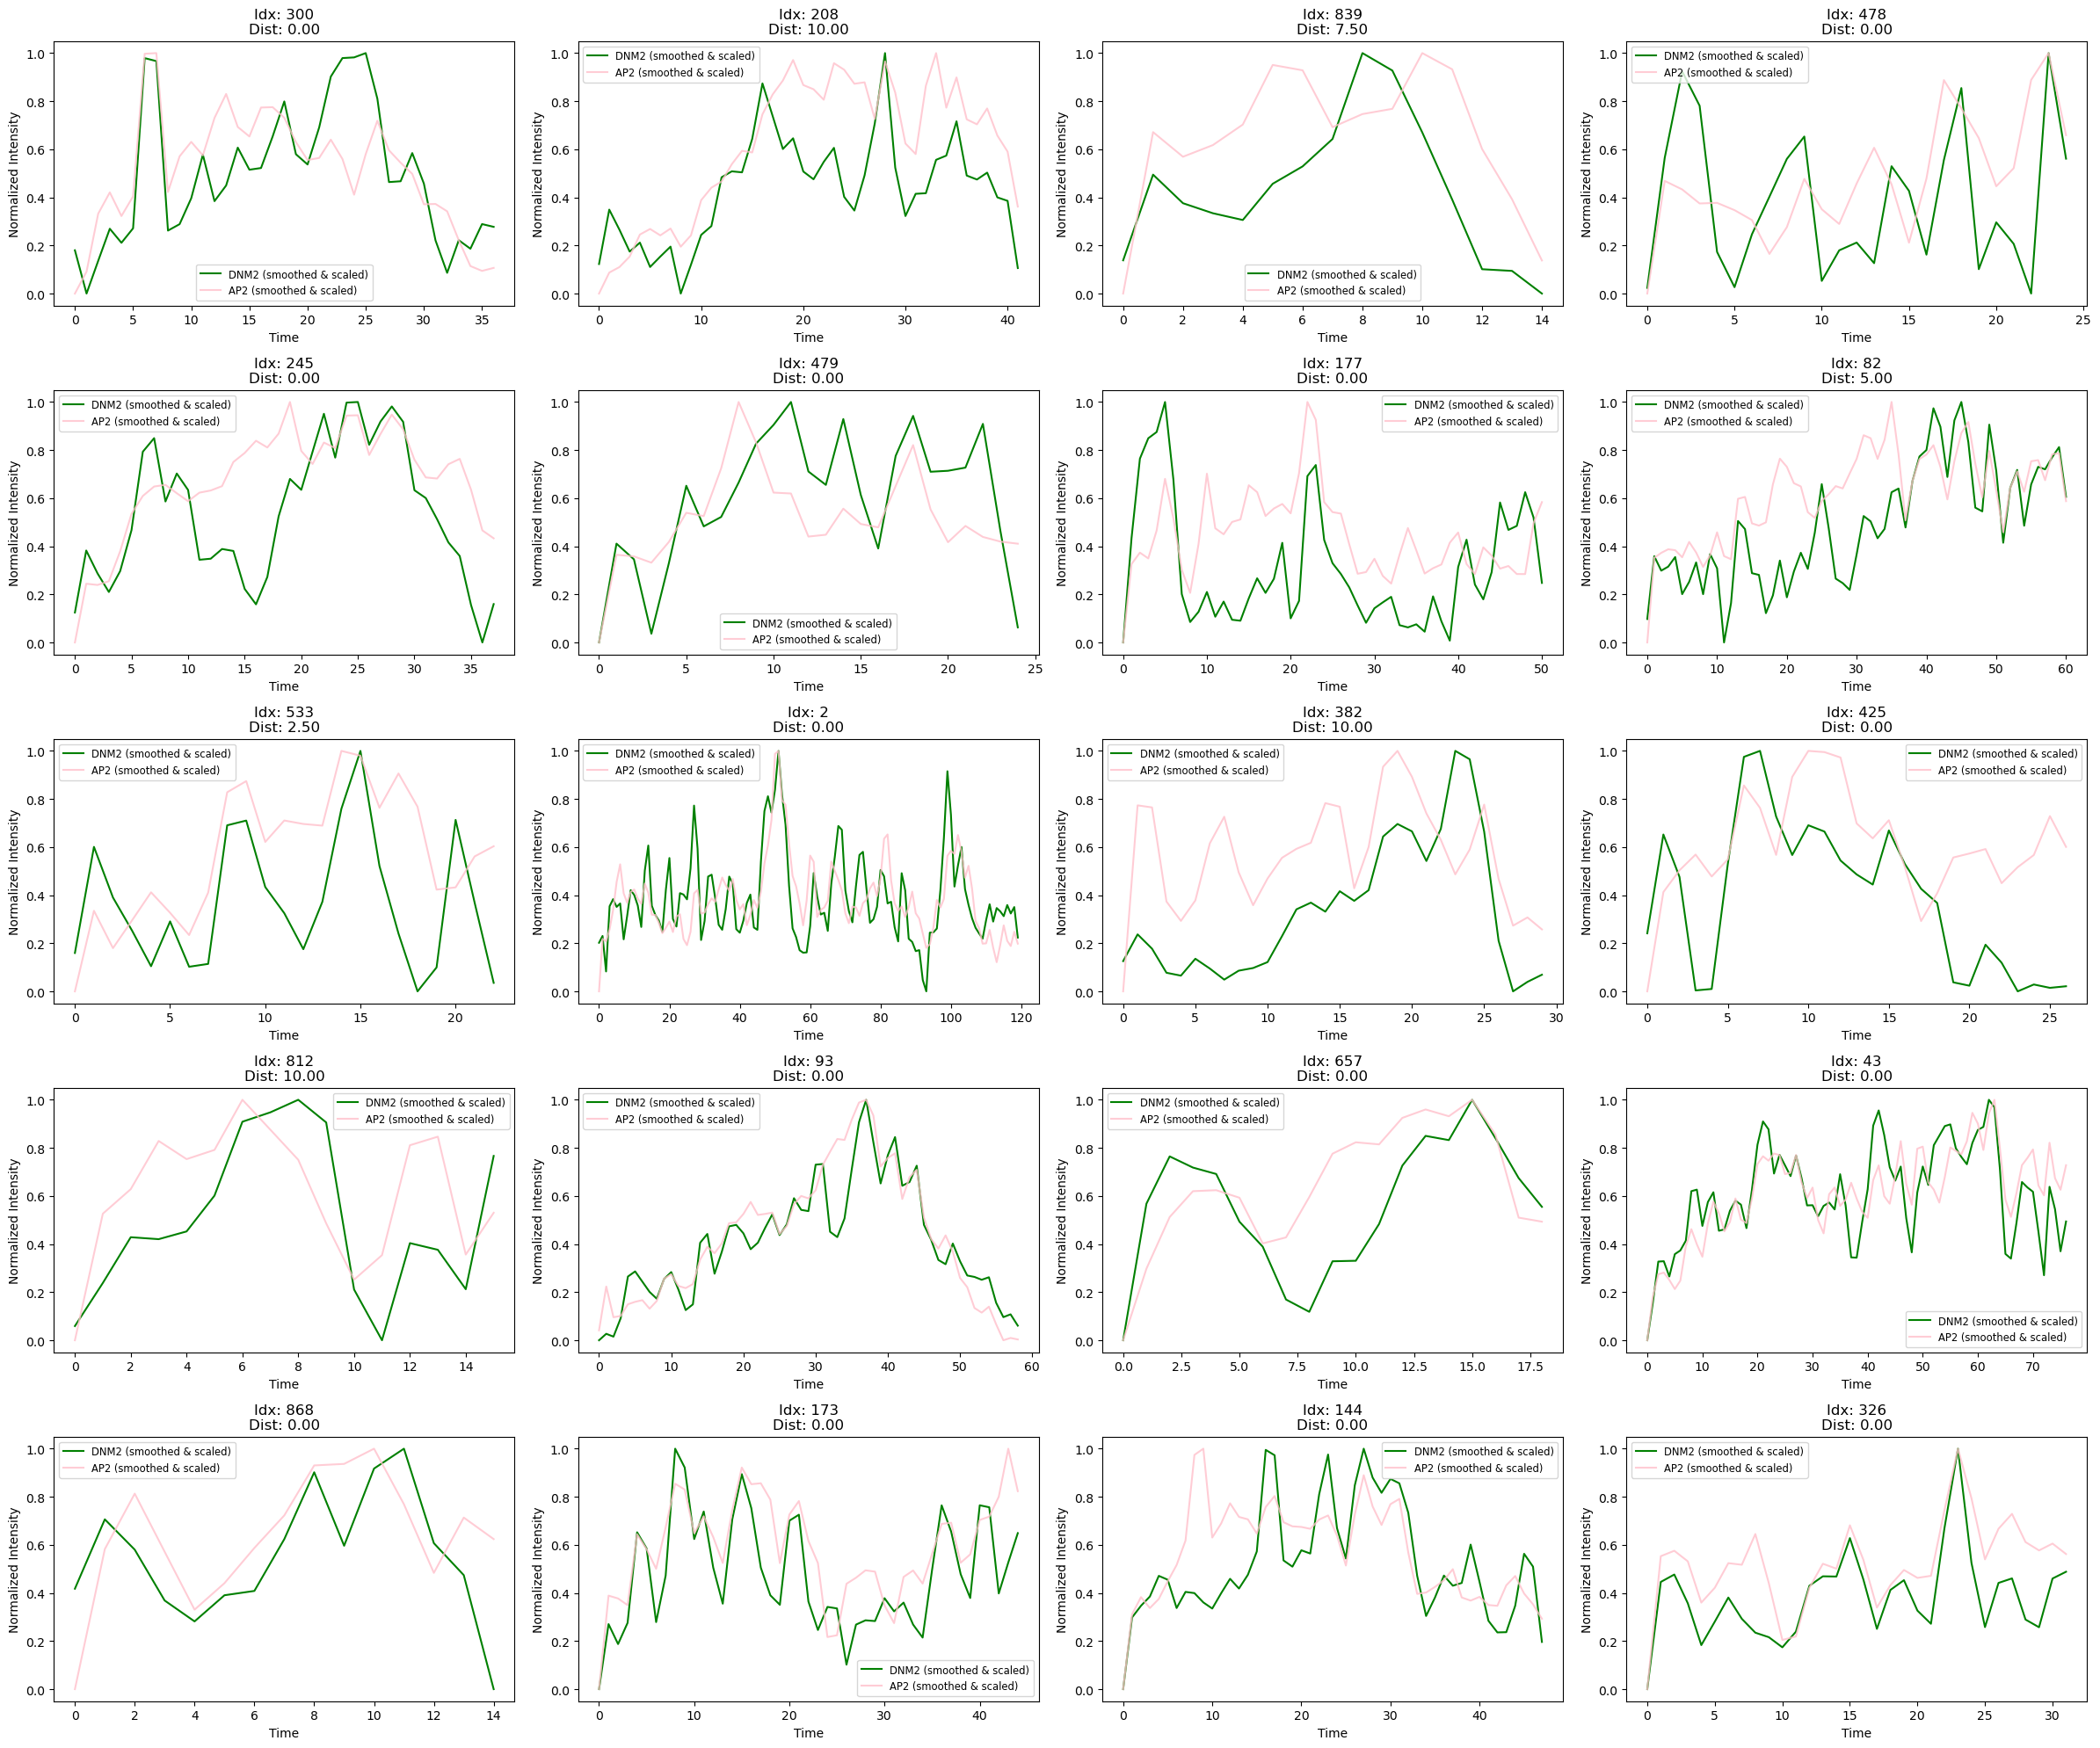

In [10]:
def moving_average(x, window=3):
    """Simple moving average with reflection padding."""
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='same')

fig, axs = plt.subplots(5, 4, figsize=(24, 20), sharex=False, sharey=False)
axs = axs.flatten()

for ax, idx in zip(axs, sample_indices):  # reuse same events
    ap2_track = np.array(ap2[idx])
    dnm2_track = np.array(dnm2[idx])

    # Apply moving average before scaling
    ap2_smooth = moving_average(ap2_track, window=2)
    dnm2_smooth = moving_average(dnm2_track, window=2)

    ap2_scaled = min_max_scale(ap2_smooth)
    dnm2_scaled = min_max_scale(dnm2_smooth)

    time_distance = closest_distances[idx] * frame_interval

    ax.plot(dnm2_scaled, color='green', label='DNM2 (smoothed & scaled)')
    ax.plot(ap2_scaled, color='pink', label='AP2 (smoothed & scaled)', alpha=0.8)
    ax.set_title(f'Idx: {idx}\nDist: {time_distance:.2f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Normalized Intensity')
    ax.legend(fontsize='small')

# Remove unused subplots
for ax in axs[len(sample_indices):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
